### Evaluate and Plot Resutls

In [1]:
# Imports
import os, sys
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib as mpl

color_cycle = ['#000000', '#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7']

# Global settings
mpl.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'figure.figsize': [3.5, 2.5],
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'axes.linewidth': 0.6,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'font.size': 8,
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'lines.linewidth': 1.0,
    'lines.markersize': 4,
    'axes.prop_cycle': mpl.cycler(color=color_cycle),
    'grid.linestyle': '--',
    'grid.linewidth': 0.3,
    'grid.alpha': 0.7,
    'legend.frameon': True,
    'legend.framealpha': None,
    'legend.facecolor': 'white',
    'legend.edgecolor': 'black',
    'legend.fontsize': 7,
    'legend.borderaxespad': 0.5,
    'legend.borderpad': 0.4,
    'legend.handlelength': 1.5,
    'legend.handletextpad': 0.4,
    'legend.labelspacing': 0.3,
    'legend.loc': 'best',
})

if "__file__" in globals():
    script_dir = os.path.dirname(os.path.abspath(__file__))
else:
    script_dir = os.getcwd()

utils_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "Utils"))
model_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "src"))
output_dir = os.path.abspath(os.path.join(script_dir, "..", "Outputs"))

sys.path.append(utils_dir)
sys.path.append(model_dir)
from data_processing import load_cluster
from yaml_processor import load_config, save_config
from sensor_processing_v2 import sensor_processing
from EDM_v1_2 import EDM




In [2]:
# Parameters
cluster = 0
chkpnt_path = os.path.join(output_dir, "model_checkpoint", str(cluster))
config_file = os.path.abspath(os.path.join(chkpnt_path, "configuration.yaml"))
config_global = load_config(config_file)

n_sparse = int(config_global["sensors"]["n_sensors"])
nx = config_global["data"]["nx"]
nt = config_global["data"]["nt"]
T = 1/np.pi
t = np.linspace(0.0, T, nt, endpoint=False)
dt = T / nt
t_max = T

In [3]:
# Set device
device = ('cuda:0' if torch.cuda.is_available() else 'cpu')
# Load Data
FS_train, params_train, ft_train, disp_norm, vel_norm, ft_norm = load_cluster(os.path.join(output_dir, "datasets", "Train"), cluster, normalize=True)
FS_val, params_val, ft_val, _, _, _ = load_cluster(os.path.join(output_dir, "datasets", "Val"), cluster, True, disp_norm, vel_norm, ft_norm)
FS_test, params_test, ft_test, _, _, _ = load_cluster(os.path.join(output_dir, "datasets", "Test"), cluster, True, disp_norm, vel_norm, ft_norm)

In [4]:
# Apply Sensor Placement
sp = sensor_processing(FS_train[:, 1], config_global)
cluster_matrix_subdir = os.path.join("compression_matrices", "clusters", str(cluster))
cluster_matrix_path = os.path.join(output_dir, cluster_matrix_subdir)
if not os.path.exists(os.path.join(cluster_matrix_path, "A_Mat.npy")):
    print(
        f"[WARN] Cluster-local matrices not found at {cluster_matrix_path}; "
        "falling back to global compression_matrices. Rerun Step_01_Clustering "
        "to generate per-cluster bases."
    )
    cluster_matrix_subdir = "compression_matrices"

A_Mat, C_Mat, pinv_Theta, sensor_placement = sp.load(
    output_dir,
    matrix_subdir=cluster_matrix_subdir,
)
RS_train, RS_val, RS_test = sp.apply_sensors(FS_train, FS_val, FS_test)

# Reshape from [samples, fields, time, sensors] to [samples, time, fields*sensors].
n_fields = RS_train.shape[1]
n_sparse_per_field = RS_train.shape[-1]
RS_train = np.concatenate([RS_train[:, i, :, :] for i in range(n_fields)], axis=-1)
RS_val = np.concatenate([RS_val[:, i, :, :] for i in range(n_fields)], axis=-1)
RS_test = np.concatenate([RS_test[:, i, :, :] for i in range(n_fields)], axis=-1)
config_global["sensors"]["sensor_mode"] = "scalar"
config_global["sensors"]["n_sensors"] = int(n_sparse_per_field)
config_global["sensors"]["num_sensors"] = int(n_sparse_per_field)

print("A_Mat shape:", A_Mat.shape)
print("C_Mat shape:", C_Mat.shape)
print("RS_train shape after reshape:", RS_train.shape)
print("n_sensors used by EDM:", config_global["sensors"]["n_sensors"])


A_Mat shape: (101, 13)
C_Mat shape: (18, 101)
RS_train shape after reshape: (15, 400, 36)
n_sensors used by EDM: 18


model = EDM(A_Mat, pinv_Theta, dt, t_max, config_global, device)
model.build_model(method="hist_moe")

# Load model
model_params = os.path.abspath(os.path.join(output_dir, "model_checkpoint", str(cluster))) + "/best_model_state_dict.pth"
model.problem.load_state_dict(torch.load(model_params, map_location=torch.device(device)))

In [5]:
model = EDM(A_Mat, pinv_Theta, dt, t_max, config_global, device)


[EDM_v1_2] Using NODE variant: RBFHistoryMoE_NODE
[EDM_v1_2] Gate losses: balance=0.1, anchor=10.0, overlap=0.5, expert_diversity=0.005; target=0.333/0.333/0.333


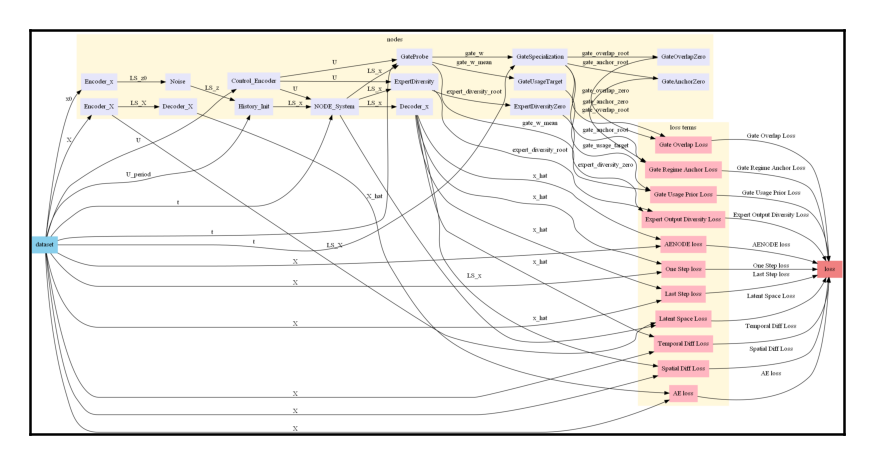

In [6]:
model.build_model(method="rbf_moe")


In [ ]:
#model_params = os.path.join(chkpnt_path, "best_model_state_dict.pth")
model_params = os.path.join(chkpnt_path, "interrupted_model_state_dict.pth")
state = torch.load(model_params, map_location=torch.device(device))
model.problem.load_state_dict(state)

<All keys matched successfully>

In [8]:
model.problem.nodes[5].nsteps = nt
model.problem.eval()

### MODEL SUMMARY ###

NODES:
  Encoder_x(x0) -> LS_z0
  Encoder_X(X) -> LS_X
  Noise(LS_z0) -> LS_z
  Control_Encoder(U) -> U
  History_Init(LS_z, U_period) -> LS_x
  System(
  (nodes): ModuleList(
    (0): NODE(LS_x, U, t) -> LS_x
  )
)
  Decoder_x(LS_x) -> x_hat
  Decoder_X(LS_X) -> X_hat
  GateProbe(LS_x, U, t) -> gate_w, gate_w_mean
  GateUsageTarget(gate_w_mean) -> gate_usage_target
  GateSpecialization(gate_w, t) -> gate_anchor_root, gate_overlap_root
  GateAnchorZero(gate_anchor_root) -> gate_anchor_zero
  GateOverlapZero(gate_overlap_root) -> gate_overlap_zero
  ExpertDiversity(LS_x, U) -> expert_diversity_root
  ExpertDiversityZero(expert_diversity_root) -> expert_diversity_zero

CONSTRAINTS: none

OBJECTIVES:
  Constraint(
  (left): slice
  (right): X
  (comparator): Eq()
)
  Constraint(
  (left): X_hat
  (right): X
  (comparator): Eq()
)
  Constraint(
  (left): slice
  (right): slice
  (comparator): Eq()
)
  Constraint(
  (left): slice
  (right): slice
  (comparator): Eq()


In [9]:
t_eval = np.ascontiguousarray(t[:, np.newaxis], dtype=np.float32)
RS_test_eval = np.ascontiguousarray(RS_test, dtype=np.float32)
ft_test_eval = np.ascontiguousarray(ft_test, dtype=np.float32)

test_t = torch.as_tensor(t_eval, dtype=torch.float32, device=device)
test_data = {
    "X": torch.as_tensor(RS_test_eval, dtype=torch.float32, device=device),
    "x0": torch.as_tensor(RS_test_eval[:, 0:1], dtype=torch.float32, device=device),
    "U": torch.as_tensor(ft_test_eval, dtype=torch.float32, device=device),
    "t": test_t.repeat(RS_test_eval.shape[0], 1, 1),
    "U_period": torch.as_tensor(ft_test_eval, dtype=torch.float32, device=device)
}

with torch.no_grad():
    outputs = model.problem.step(test_data)


In [10]:
# The corrected graph already computes gate weights through GateProbe.
node_block = model._gate_node

with torch.no_grad():
    if "gate_w" not in outputs:
        raise KeyError(
            "gate_w was not produced. Confirm that the corrected "
            "EDM_v1_2.py is installed and that the model was built "
            "with method='rbf_moe'."
        )

    # Shape: [number of trajectories, nt, number of experts]
    gate_weights = outputs["gate_w"].detach().cpu().numpy()

    # Average across test trajectories for the time-domain plot.
    weights = gate_weights.mean(axis=0)

    gate_centers = (
        node_block.gate.centers
        .detach()
        .cpu()
        .numpy()
    )

    gate_sigma = (
        node_block.gate.sigma
        .detach()
        .cpu()
        .numpy()
    )

print("gate_weights shape:", gate_weights.shape)
print("mean expert usage:", gate_weights.mean(axis=(0, 1)))

gate_weights shape: (64, 400, 3)
mean expert usage: [0.4701192  0.05948388 0.47039682]


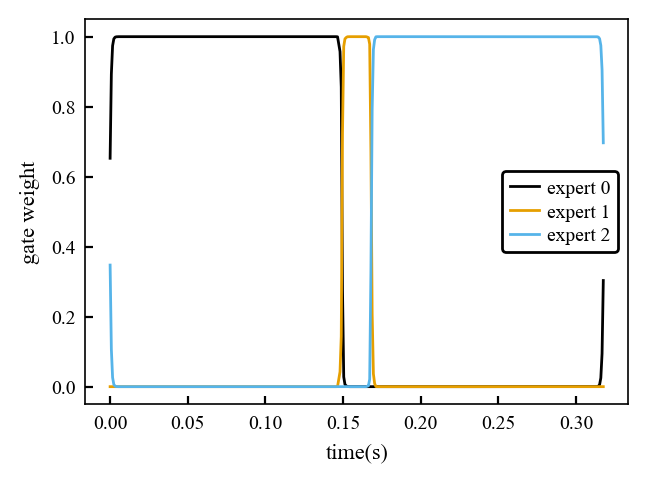

In [11]:
plt.figure(dpi=200)
for i in range(weights.shape[1]):
    plt.plot(t, weights[:, i], label=f"expert {i}")
#plt.plot(t, ft_test[:,:,0].T)
plt.xlabel("time(s)")
plt.ylabel("gate weight")
plt.legend()
plt.show()


In [12]:
n_samples, n_fields, nt_data, nx_data = FS_test.shape
FS_reshaped = np.concatenate([FS_test[:, i, :, :] for i in range(n_fields)], axis=-1)
FS_LS = outputs["LS_X"].cpu().detach().numpy() if "LS_X" in outputs else None
FS_AE_sparse = outputs["X_hat"].cpu().detach().numpy()
FS_pred_sparse = outputs["x_hat"][:, :-1, :].cpu().detach().numpy()

C_recon = (A_Mat @ pinv_Theta).T

def lift_sparse_state(X_sparse):
    disp = X_sparse[..., :n_sparse] @ C_recon
    vel = X_sparse[..., n_sparse:] @ C_recon
    return np.concatenate([disp, vel], axis=-1)


FS_AE = lift_sparse_state(FS_AE_sparse)
FS_pred = lift_sparse_state(FS_pred_sparse)
print("FS_reshaped shape:", FS_reshaped.shape)
print("FS_AE_sparse shape:", FS_AE_sparse.shape)
print("FS_pred_sparse shape:", FS_pred_sparse.shape)
print("FS_AE full shape:", FS_AE.shape)
print("FS_pred full shape:", FS_pred.shape)


FS_reshaped shape: (64, 400, 202)
FS_AE_sparse shape: (64, 400, 36)
FS_pred_sparse shape: (64, 400, 36)
FS_AE full shape: (64, 400, 202)
FS_pred full shape: (64, 400, 202)


In [13]:
ae_sparse_frob_error = np.linalg.norm(FS_AE_sparse - RS_test) / np.linalg.norm(RS_test)
ae_full_frob_error = np.linalg.norm(FS_AE - FS_reshaped) / np.linalg.norm(FS_reshaped)
node_full_frob_error = np.linalg.norm(FS_pred - FS_reshaped) / np.linalg.norm(FS_reshaped)

print(f"Frob norm for AE (sparse space) is : {ae_sparse_frob_error}")
print(f"Frob norm for AE (full lifted space) is : {ae_full_frob_error}")
print(f"Frob norm for NODE (full lifted space) is : {node_full_frob_error}")

Frob norm for AE (sparse space) is : 0.030829102621483338
Frob norm for AE (full lifted space) is : 0.031601707463049446
Frob norm for NODE (full lifted space) is : 0.1437152250062054


In [20]:
ae_node_frob_difference = np.linalg.norm(FS_pred - FS_AE) / np.linalg.norm(FS_AE)
print(f"Frob norm for AE-NODE Difference is : {ae_node_frob_difference}")

Frob norm for AE-NODE Difference is : 0.16473934705535245


In [15]:
errs = np.zeros((FS_reshaped.shape[0],))

In [16]:
for i in range(FS_reshaped.shape[0]):
    errs[i] = np.linalg.norm(FS_pred[i]-FS_reshaped[i])/np.linalg.norm(FS_reshaped[i])

In [23]:
# Export helpers for evaluation plotting bundles.
evaluation_plot_data_dir = os.path.join(chkpnt_path, "evaluation_plot_data")


def _json_safe(value):
    if isinstance(value, torch.Tensor):
        return _json_safe(value.detach().cpu().numpy())
    if isinstance(value, np.ndarray):
        if value.ndim == 0:
            return _json_safe(value.item())
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, dict):
        return {str(key): _json_safe(val) for key, val in value.items()}
    if isinstance(value, (list, tuple)):
        return [_json_safe(item) for item in value]
    if isinstance(value, (str, int, float, bool)) or value is None:
        return value
    return str(value)


def _as_export_array(value):
    if isinstance(value, torch.Tensor):
        value = value.detach().cpu().numpy()
    elif isinstance(value, np.generic):
        value = value.item()
    return np.asarray(value)


def _array_summary(arr):
    arr = np.asarray(arr)
    return {"shape": list(arr.shape), "dtype": str(arr.dtype)}


def _collect_evaluation_plot_arrays(scope):
    required_names = [
        "t", "t_eval", "T", "dt", "t_long", "t_cycle",
        "RS_train", "RS_val", "RS_test", "RS_test_eval", "ft_train", "ft_val", "ft_test", "ft_test_eval",
        "params_train", "params_val", "params_test", "disp_norm", "vel_norm", "ft_norm",
        "A_Mat", "C_Mat", "pinv_Theta", "sensor_placement", "C_recon",
        "gate_centers", "gate_sigma", "gate_weights",
        "FS_reshaped", "FS_LS", "FS_AE_sparse", "FS_pred_sparse", "FS_AE", "FS_pred", "errs",
        "idx", "num_cycles", "RS_test_long", "ft_test_long", "FS_reshaped_long", "FS_AE_long", "FS_pred_long",
        "F_true", "Pxx_true", "F_pred", "Pxx_pred",
    ]
    optional_names = ["p", "x", "ind", "lim"]
    arrays = {}
    missing = []

    for name in required_names:
        if name not in scope or scope[name] is None:
            missing.append(name)
            continue
        arrays[name] = _as_export_array(scope[name])

    for name in optional_names:
        if name in scope and scope[name] is not None:
            arrays[name] = _as_export_array(scope[name])

    return arrays, missing


def write_evaluation_plot_bundle(scope):
    os.makedirs(evaluation_plot_data_dir, exist_ok=True)
    plot_arrays, missing_arrays = _collect_evaluation_plot_arrays(scope)

    npz_path = os.path.join(evaluation_plot_data_dir, "evaluation_plot_data.npz")
    np.savez_compressed(npz_path, **plot_arrays)

    array_summaries = {name: _array_summary(arr) for name, arr in plot_arrays.items()}
    metadata = {
        "cluster": int(cluster),
        "chkpnt_path": os.path.abspath(chkpnt_path),
        "evaluation_plot_data_dir": os.path.abspath(evaluation_plot_data_dir),
        "model_params": os.path.abspath(model_params),
        "config_file": os.path.abspath(config_file),
        "cluster_matrix_subdir": cluster_matrix_subdir,
        "n_fields": int(n_fields),
        "n_sparse_per_field": int(n_sparse_per_field),
        "n_sparse": int(n_sparse),
        "nx": int(nx),
        "nt": int(nt),
        "scalar_error_metrics": {
            "ae_sparse_frob_error": ae_sparse_frob_error,
            "ae_full_frob_error": ae_full_frob_error,
            "node_full_frob_error": node_full_frob_error,
            "ae_node_frob_difference": ae_node_frob_difference,
            "long_ae_full_frob_error": long_ae_full_frob_error,
            "long_node_full_frob_error": long_node_full_frob_error,
        },
        "array_summaries": array_summaries,
        "missing_arrays": missing_arrays,
        "source_dataset_paths": {
            "Train": os.path.abspath(os.path.join(output_dir, "datasets", "Train", str(cluster))),
            "Val": os.path.abspath(os.path.join(output_dir, "datasets", "Val", str(cluster))),
            "Test": os.path.abspath(os.path.join(output_dir, "datasets", "Test", str(cluster))),
        },
        "config_global": config_global,
    }

    metadata_path = os.path.join(evaluation_plot_data_dir, "evaluation_plot_metadata.json")
    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(_json_safe(metadata), f, indent=2)

    print(f"Saved evaluation plotting arrays to {npz_path}")
    print(f"Saved evaluation plotting metadata to {metadata_path}")
    if missing_arrays:
        print(f"Skipped missing arrays: {missing_arrays}")

    return {"npz_path": npz_path, "metadata_path": metadata_path, "missing_arrays": missing_arrays}


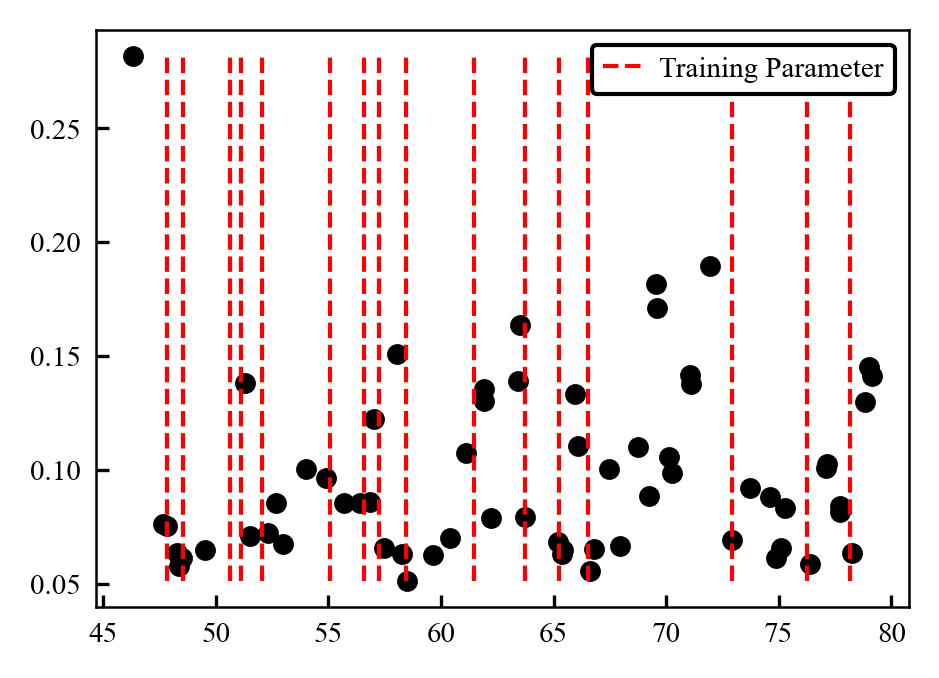

In [17]:
plt.figure()
plt.scatter(params_test, errs, marker='o')
plt.vlines(params_train, ymin=errs.min(), ymax=errs.max(), colors='r', linestyles='dashed', label='Training Parameter')
plt.legend()
plt.show()

## Params and Sensors

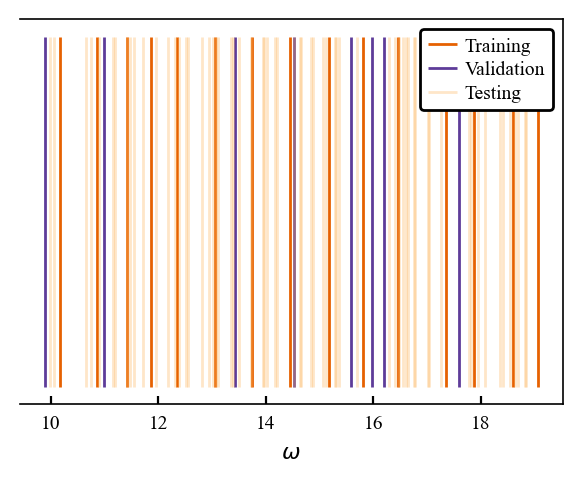

In [ ]:
# Params scatter
plt.figure(dpi=200)
plt.tight_layout()
plt.vlines(params_train[:, 0], ymin=-1, ymax=1, colors="#e66101", label="Training")
plt.vlines(params_val[:, 0], ymin=-1, ymax=1, colors="#5e3c99", label="Validation")
plt.vlines(params_test[:, 0], ymin=-1, ymax=1, colors="#fdb863", alpha = 0.35, label="Testing")
plt.yticks([])
ax = plt.gca()
ax.spines['left'].set_visible(False)
plt.xlabel(r"$\omega$")
plt.legend(loc="upper right")
plt.show()

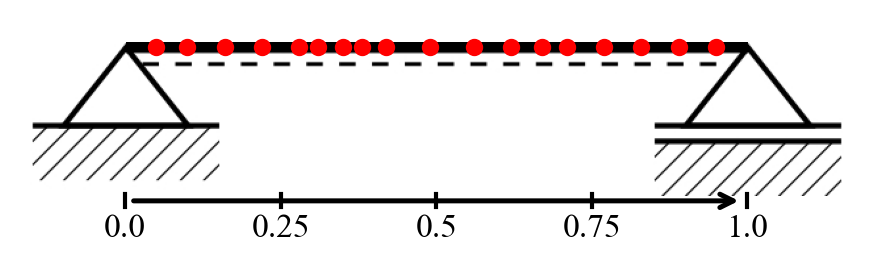

In [19]:
# Sensor Locations
beam = mpimg.imread("supplementary/beam.jpg")
height, width = beam.shape[:2]
xbounds = np.array([72, 545])
xs = (sensor_placement/100)*(xbounds[1]-xbounds[0])+xbounds[0]
ys = np.array([3]*len(sensor_placement))
plt.imshow(beam)
plt.scatter(xs, ys, c='red', s=10, marker='o')  # Customize as needed
plt.axis('off')

x0, y0 = xbounds[0], 120
x_axis_len = xbounds[1]-xbounds[0]
plt.annotate('', xy=(x0 + x_axis_len, y0), xytext=(x0, y0),
            arrowprops=dict(arrowstyle='->', color='black', linewidth=1.2))
xticks = np.linspace(0, 100, 5)
for val in xticks:
    x_tick_pos = x0 + val / 100 * x_axis_len
    plt.plot([x_tick_pos, x_tick_pos], [y0 - 5, y0 + 5], color='black', linewidth=1)
    plt.text(x_tick_pos, y0 + 10, f'{float(val/100)}', ha='center', va='top', fontsize=8)
plt.ylim(height+10, -10)
plt.show()

## Results Plots

### Latent Space

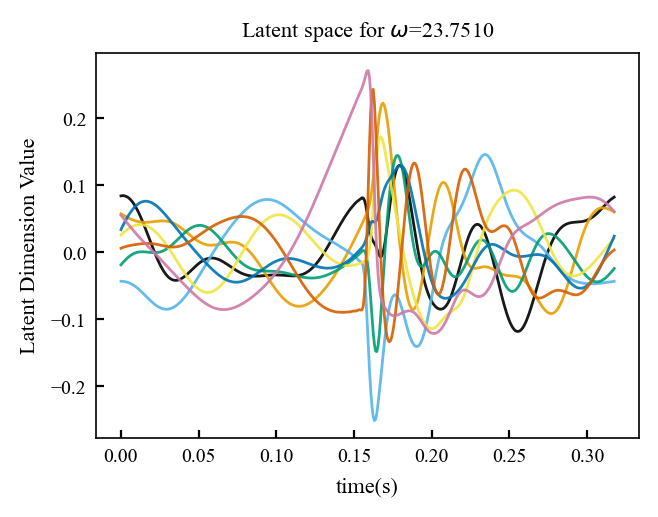

In [17]:
## Latent Spaces
p=4
plt.figure(dpi=200)
plt.plot(t, FS_LS[p, :], alpha=0.9)
plt.xlabel("time(s)")
plt.ylabel("Latent Dimension Value")
plt.title(fr"Latent space for $\omega$={params_test[p,0]:.4f}")
plt.show()

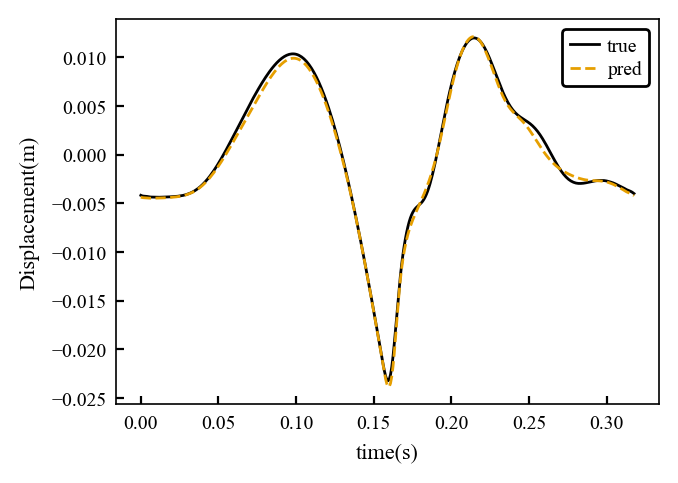

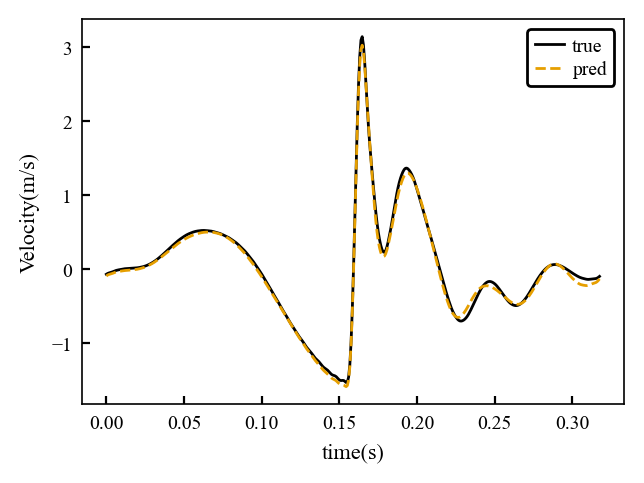

In [18]:
p = 5
x = 75
# Displacement
plt.figure(dpi=200)
plt.tight_layout()
plt.plot(t, FS_reshaped[p, :, x]*disp_norm, label="true")
plt.plot(t, FS_AE[p, :, x]*disp_norm, '--', label="pred")

plt.ylabel("Displacement(m)")
plt.xlabel("time(s)")
plt.legend()
plt.show()

# Velocity
plt.figure(dpi=200)
plt.tight_layout()
plt.plot(t, FS_reshaped[p, :, x+nx]*vel_norm, label="true")
plt.plot(t, FS_AE[p, :, x+nx]*vel_norm, '--', label="pred")

plt.ylabel("Velocity(m/s)")
plt.xlabel("time(s)")
plt.legend()
plt.show()

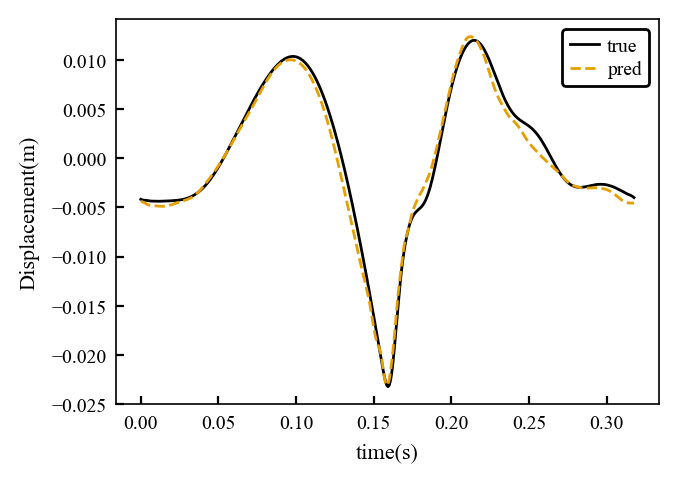

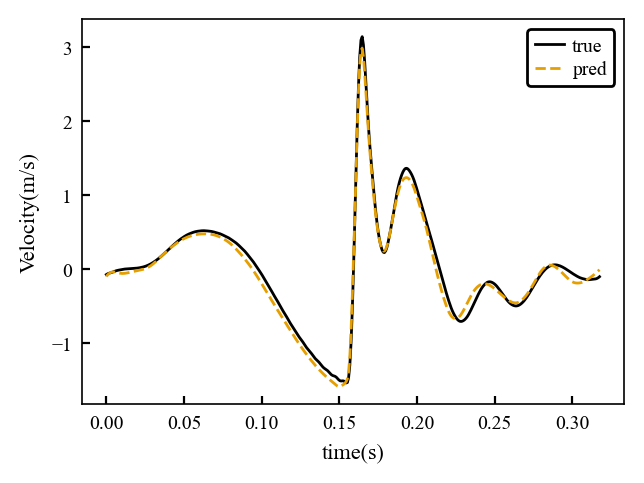

In [19]:
# Single cycle timeline plot
p = 5
x = 75
# Displacement
plt.figure(dpi=200)
plt.tight_layout()
plt.plot(t, FS_reshaped[p, :, x]*disp_norm, label="true")
plt.plot(t, FS_pred[p, :, x]*disp_norm, '--', label="pred")

plt.ylabel("Displacement(m)")
plt.xlabel("time(s)")
plt.legend()
plt.show()

# Velocity
plt.figure(dpi=200)
plt.tight_layout()
plt.plot(t, FS_reshaped[p, :, x+nx]*vel_norm, label="true")
plt.plot(t, FS_pred[p, :, x+nx]*vel_norm, '--', label="pred")

plt.ylabel("Velocity(m/s)")
plt.xlabel("time(s)")
plt.legend()
plt.show()

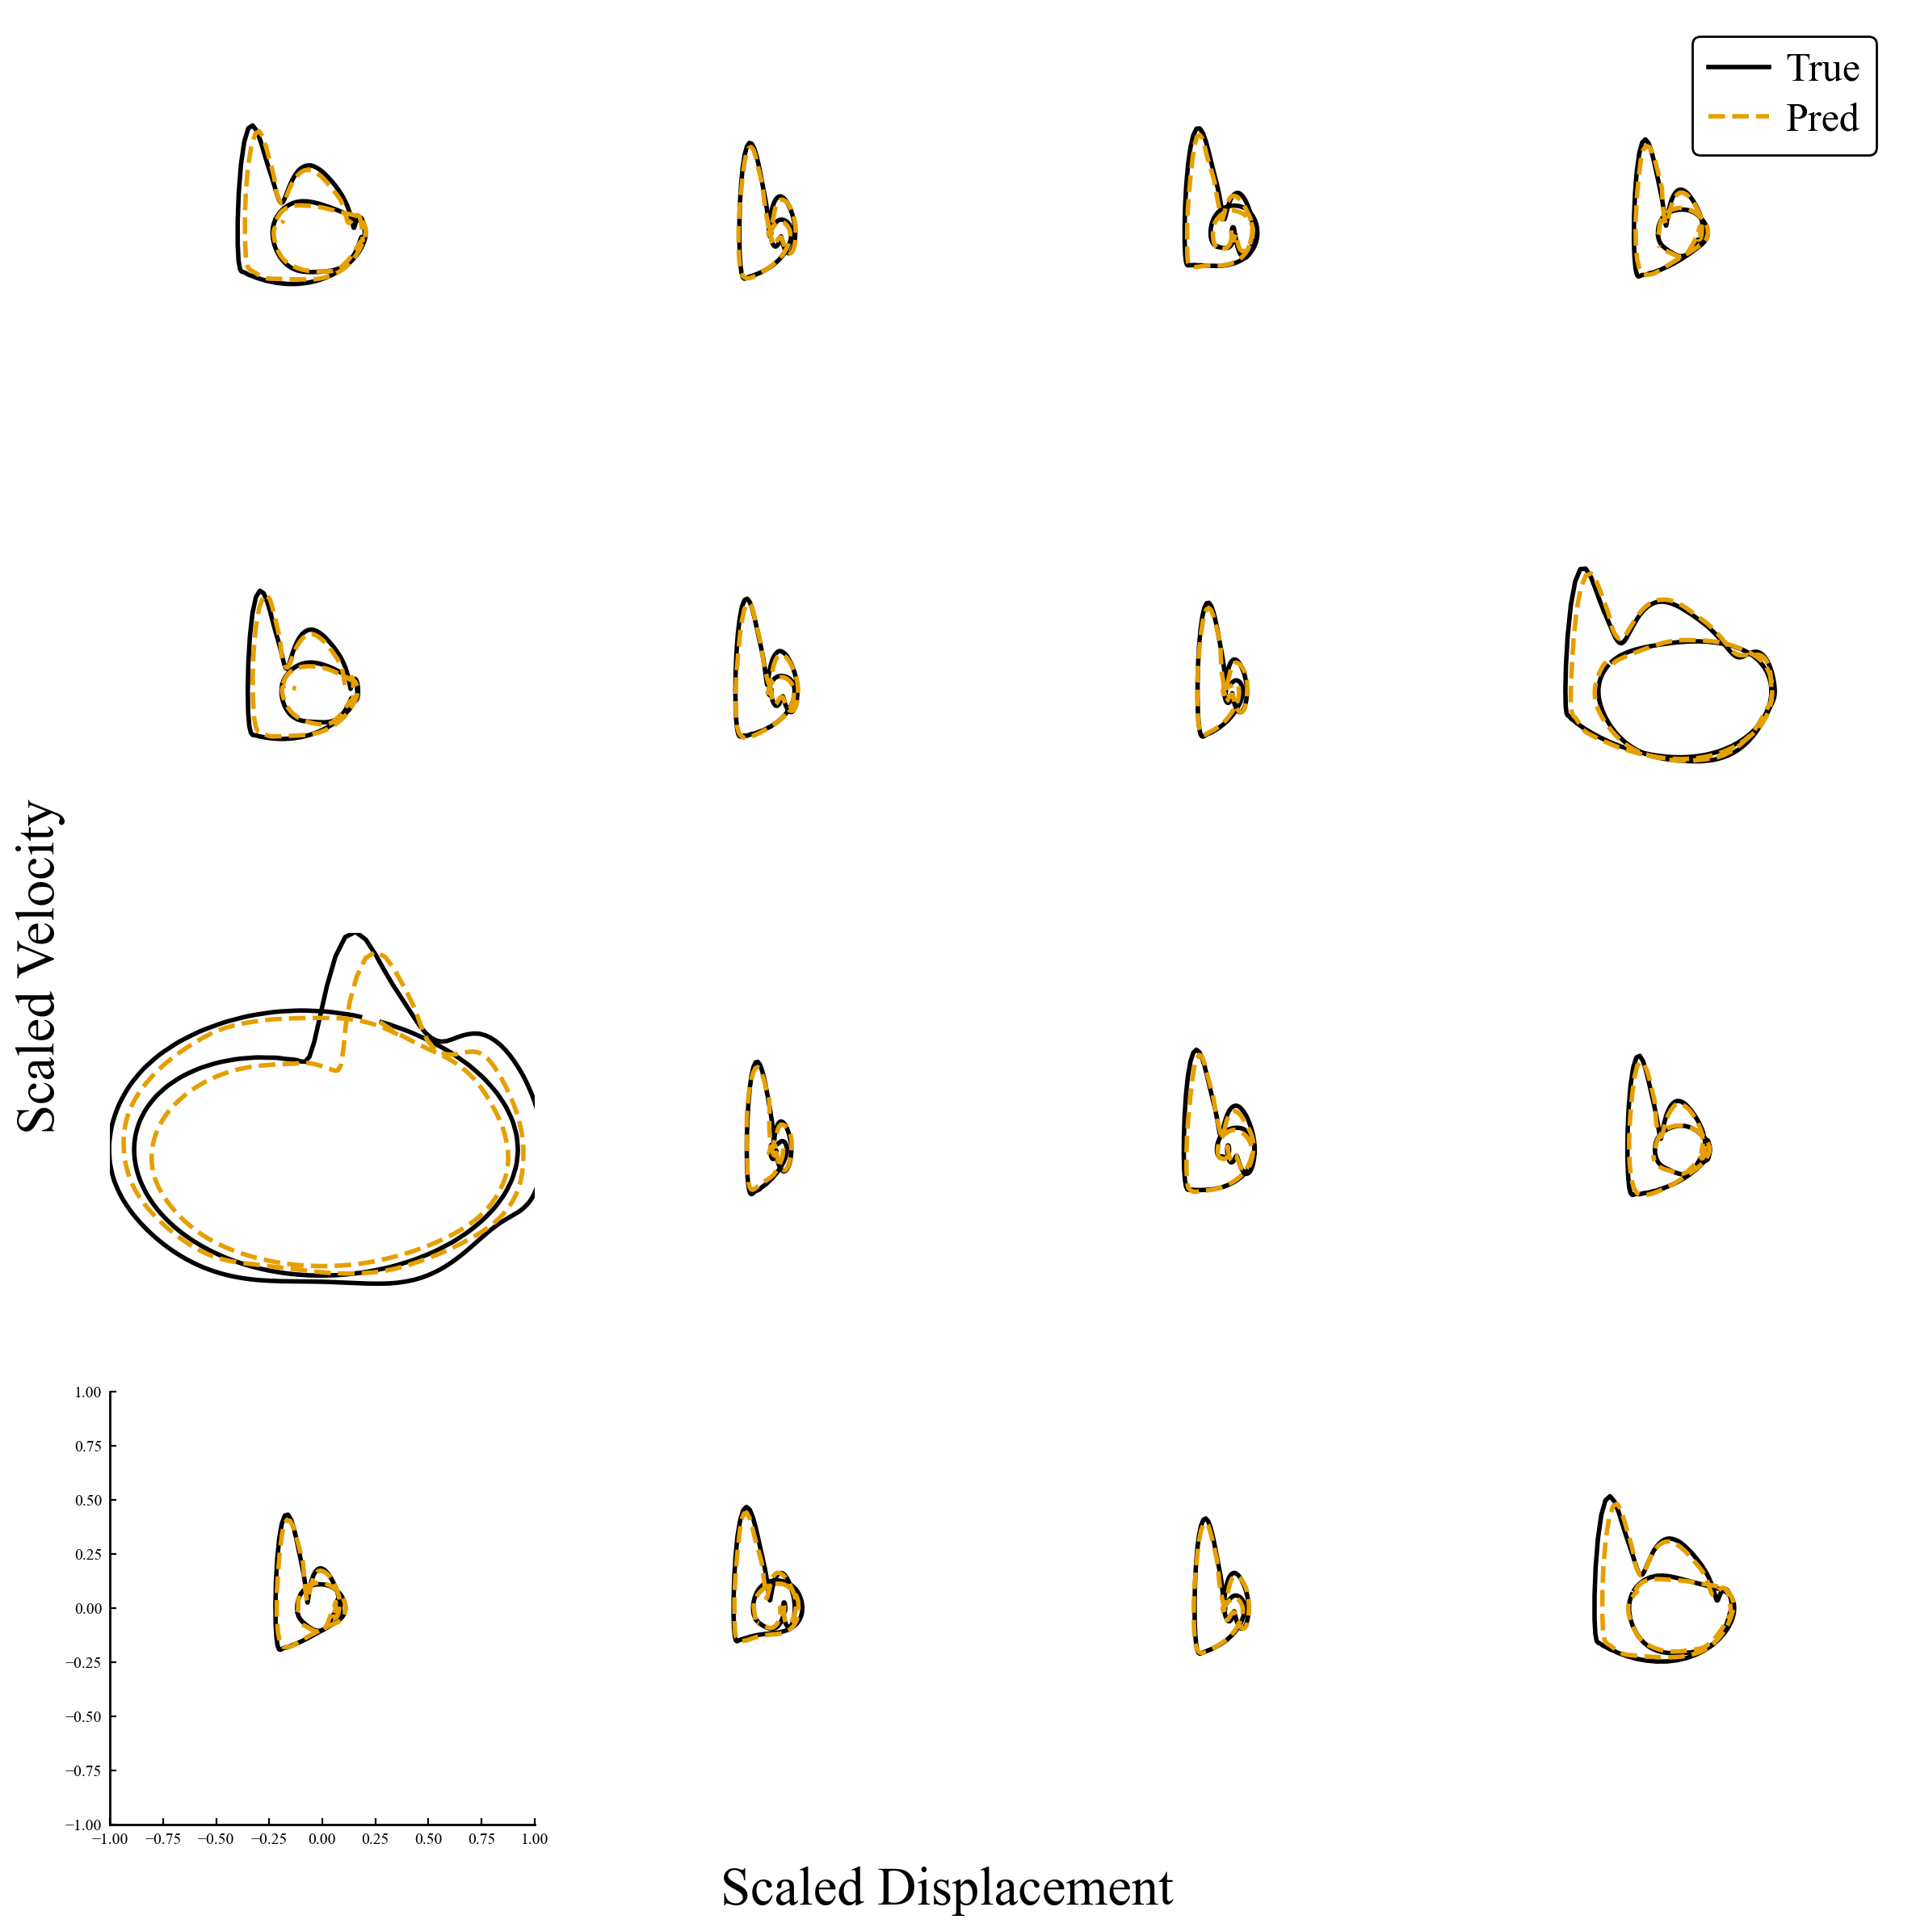

In [20]:
# 4x4 phase plane plots
fig, axes = plt.subplots(4, 4, figsize=(12, 12), dpi=200)
ind = np.linspace(0, 15, 16, dtype=np.int32)
x = 75

it = 0
for i in range(4):
    for j in range(4):
        ax = axes[i, j]
        line1, = ax.plot(FS_reshaped[ind[it], :, x], FS_reshaped[ind[it], :, x+nx], linewidth = 2, label='True')
        line2, = ax.plot(FS_pred[ind[it], :, x], FS_pred[ind[it], :, x+nx], '--', linewidth = 2, label='Pred')

        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)

        # Remove all ticks and labels
        ax.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)
        ax.set_facecolor('none')

        # Remove spines (borders)
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Only show axis on bottom-left plot
        if i == 3 and j == 0:
            ax.tick_params(labelbottom=True, labelleft=True, bottom=True, left=True)

            # Enable only left and bottom spines
            ax.spines['left'].set_visible(True)
            ax.spines['bottom'].set_visible(True)
            ax.spines['left'].set_linewidth(1)
            ax.spines['bottom'].set_linewidth(1)

            # Ensure the other two remain hidden
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

        # Add legend only on top-right plot
        if i == 0 and j == 3:
            ax.legend(handles=[line1, line2], loc='upper right', fontsize=18)

        it += 1

fig.supxlabel('Scaled Displacement', fontsize=24)
fig.supylabel('Scaled Velocity', fontsize=24)
plt.tight_layout()
plt.show()

## Longer Predictions

In [22]:
num_cycles = 12
model.problem.nodes[5].nsteps = nt * num_cycles
model.problem.eval()


### MODEL SUMMARY ###

NODES:
  Encoder_x(x0) -> LS_z0
  Encoder_X(X) -> LS_X
  Noise(LS_z0) -> LS_z
  Control_Encoder(U) -> U
  History_Init(LS_z, U_period) -> LS_x
  System(
  (nodes): ModuleList(
    (0): NODE(LS_x, U, t) -> LS_x
  )
)
  Decoder_x(LS_x) -> x_hat
  Decoder_X(LS_X) -> X_hat
  GateProbe(LS_x, U, t) -> gate_w, gate_w_mean
  GateUsageTarget(gate_w_mean) -> gate_usage_target
  GateSpecialization(gate_w, t) -> gate_anchor_root, gate_overlap_root
  GateAnchorZero(gate_anchor_root) -> gate_anchor_zero
  GateOverlapZero(gate_overlap_root) -> gate_overlap_zero
  ExpertDiversity(LS_x, U) -> expert_diversity_root
  ExpertDiversityZero(expert_diversity_root) -> expert_diversity_zero

CONSTRAINTS: none

OBJECTIVES:
  Constraint(
  (left): slice
  (right): X
  (comparator): Eq()
)
  Constraint(
  (left): X_hat
  (right): X
  (comparator): Eq()
)
  Constraint(
  (left): slice
  (right): slice
  (comparator): Eq()
)
  Constraint(
  (left): slice
  (right): slice
  (comparator): Eq()


In [23]:
idx = np.arange(min(4, RS_test.shape[0]))
RS_test_long = np.concatenate([RS_test[idx]] * num_cycles, axis=1)
ft_test_long = np.concatenate([ft_test[idx]] * num_cycles, axis=1)
t_cycle = np.ascontiguousarray(t[:, np.newaxis], dtype=np.float32)
t_long = np.concatenate([t_cycle] * num_cycles, axis=0)

test_data_long = {
    "X": torch.as_tensor(RS_test_long, dtype=torch.float32, device=device),
    "x0": torch.as_tensor(RS_test_long[:, 0:1], dtype=torch.float32, device=device),
    "U": torch.as_tensor(ft_test_long, dtype=torch.float32, device=device),
    "t": torch.as_tensor(t_long, dtype=torch.float32, device=device).repeat(len(idx), 1, 1),
    "U_period": torch.as_tensor(
    np.ascontiguousarray(ft_test[idx], dtype=np.float32),
    dtype=torch.float32,
    device=device,
)
}
outputs_long = model.problem.step(test_data_long)


In [24]:
FS_AE_long = lift_sparse_state(outputs_long["X_hat"].cpu().detach().numpy())
FS_pred_long = lift_sparse_state(outputs_long["x_hat"][:, :-1, :].cpu().detach().numpy())
FS_reshaped_long = np.concatenate([FS_test[idx, i, :, :] for i in range(n_fields)], axis=-1)
FS_reshaped_long = np.concatenate([FS_reshaped_long] * num_cycles, axis=1)

print("Long true shape:", FS_reshaped_long.shape)
print("Long AE shape:", FS_AE_long.shape)
print("Long pred shape:", FS_pred_long.shape)


Long true shape: (4, 4800, 202)
Long AE shape: (4, 4800, 202)
Long pred shape: (4, 4800, 202)


In [25]:
long_ae_full_frob_error = np.linalg.norm(FS_AE_long - FS_reshaped_long) / np.linalg.norm(FS_reshaped_long)
long_node_full_frob_error = np.linalg.norm(FS_pred_long - FS_reshaped_long) / np.linalg.norm(FS_reshaped_long)

print(f"Frob norm for AE (full lifted space) is : {long_ae_full_frob_error}")
print(f"Frob norm for NODE (full lifted space) is : {long_node_full_frob_error}")

Frob norm for AE (full lifted space) is : 0.027873482764606047
Frob norm for NODE (full lifted space) is : 0.10863988097907597


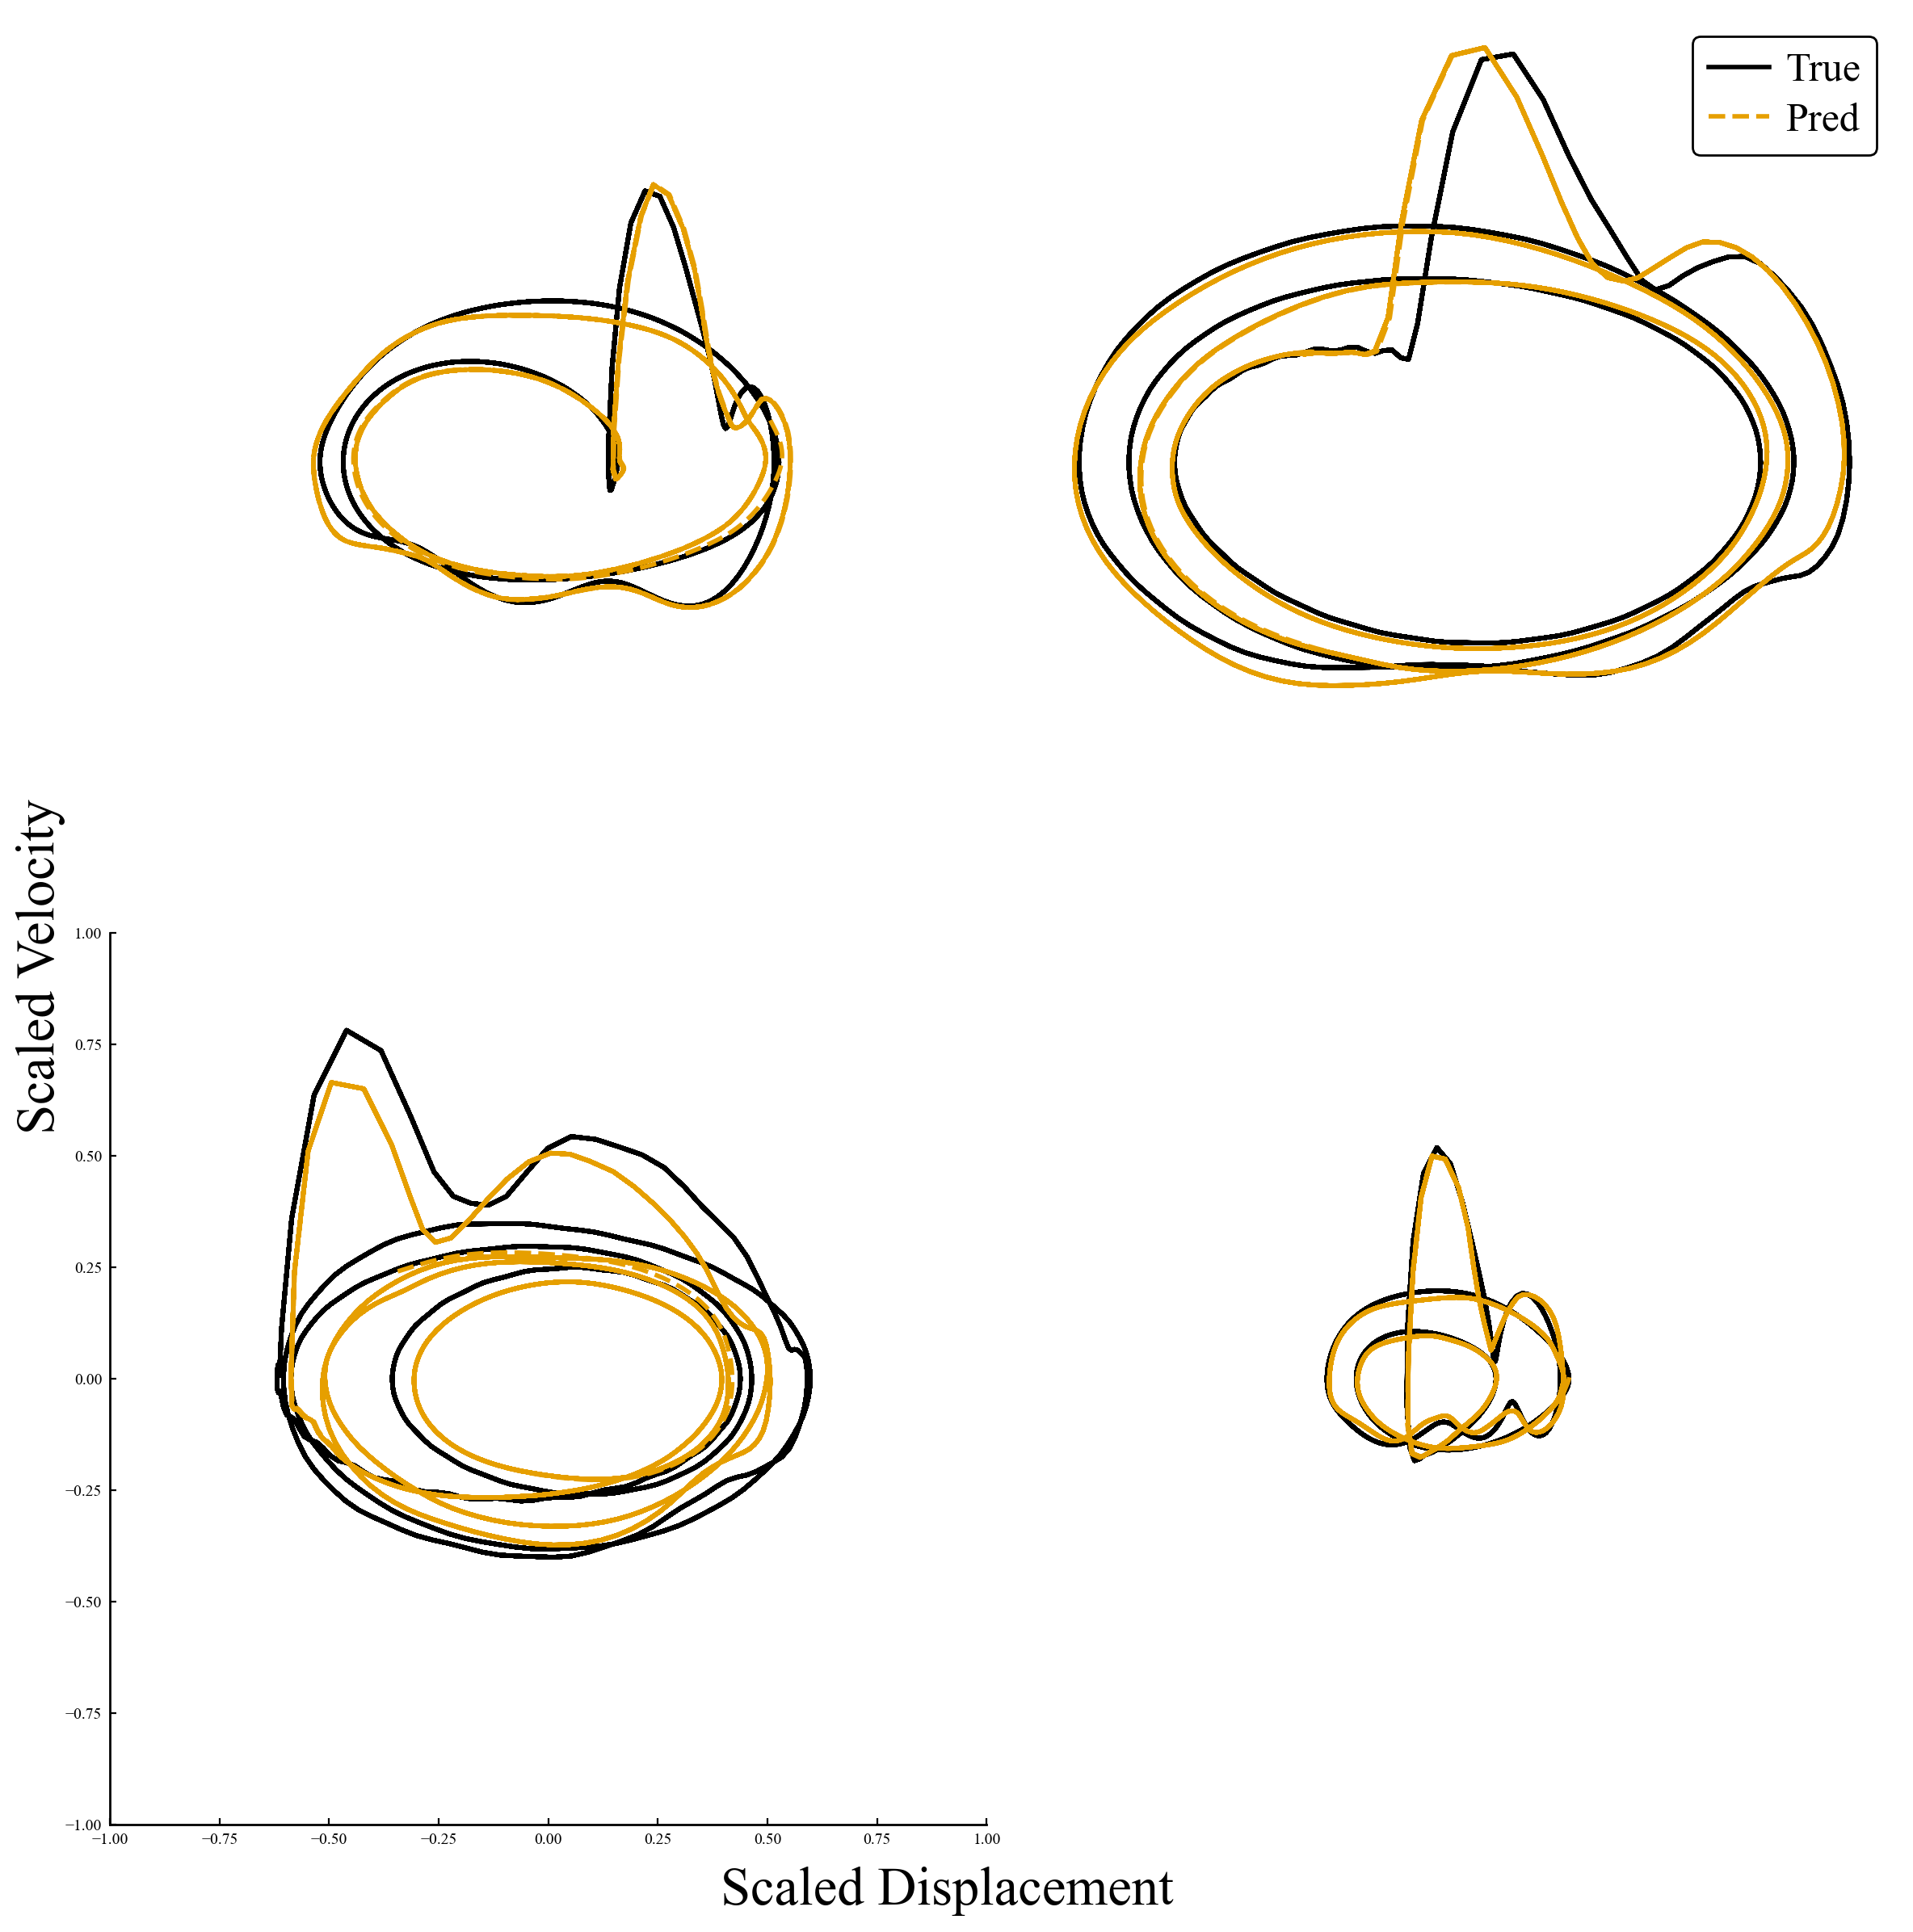

In [26]:
# 4x4 phase plane plots
fig, axes = plt.subplots(2, 2, figsize=(12, 12), dpi=200)
ind = np.linspace(0, 3, 4, dtype=np.int32)
x = 75

it = 0
for i in range(2):
    for j in range(2):
        ax = axes[i, j]
        line1, = ax.plot(FS_reshaped_long[ind[it], :, x], FS_reshaped_long[ind[it], :, x+nx], linewidth = 2, label='True')
        line2, = ax.plot(FS_pred_long[ind[it], :, x], FS_pred_long[ind[it], :, x+nx], '--', linewidth = 2, label='Pred')

        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)

        # Remove all ticks and labels
        ax.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)
        ax.set_facecolor('none')

        # Remove spines (borders)
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Only show axis on bottom-left plot
        if i == 1 and j == 0:
            ax.tick_params(labelbottom=True, labelleft=True, bottom=True, left=True)

            # Enable only left and bottom spines
            ax.spines['left'].set_visible(True)
            ax.spines['bottom'].set_visible(True)
            ax.spines['left'].set_linewidth(1)
            ax.spines['bottom'].set_linewidth(1)

            # Ensure the other two remain hidden
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

        # Add legend only on top-right plot
        if i == 0 and j == 1:
            ax.legend(handles=[line1, line2], loc='upper right', fontsize=18)

        it += 1

fig.supxlabel('Scaled Displacement', fontsize=24)
fig.supylabel('Scaled Velocity', fontsize=24)
plt.tight_layout()
plt.show()

In [27]:
from psd import psd_cutoff, psd_custom

In [28]:
lim = 300
psd_time = np.linspace(0, T * num_cycles, nt * num_cycles)
F_true, Pxx_true = psd_custom(psd_time, FS_reshaped_long[0, :, 75])
F_pred, Pxx_pred = psd_custom(psd_time, FS_pred_long[0, :, 75])

In [29]:
evaluation_export_report = write_evaluation_plot_bundle(globals())

NameError: name 'write_evaluation_plot_bundle' is not defined

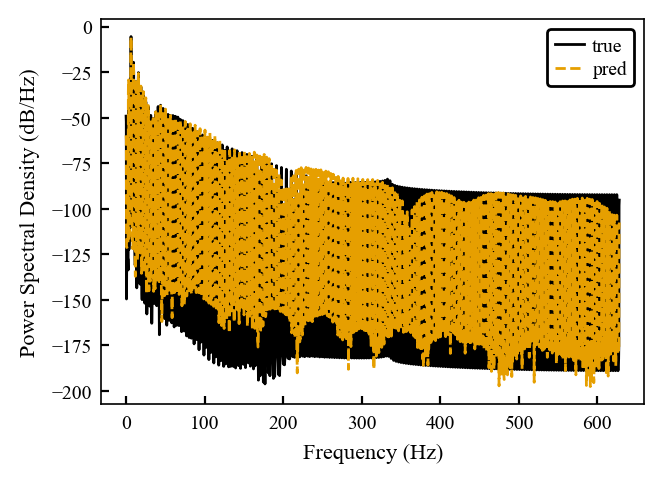

In [31]:
lim = 3000
plt.figure(dpi=200)
plt.plot(F_true[:lim], Pxx_true[:lim], label='true')
plt.plot(F_pred[:lim], Pxx_pred[:lim], '--', label='pred')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB/Hz)")
plt.legend()
plt.show()

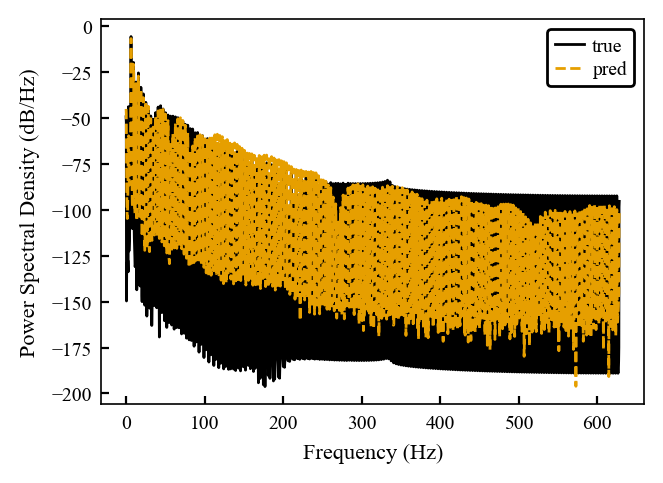

In [33]:
plt.figure(dpi=200)
plt.plot(F_true, Pxx_true, label='true')
plt.plot(F_pred, Pxx_pred, '--', label='pred')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB/Hz)")
plt.legend()
plt.show()

## Attractor study

## Local phase-plane field plots



In [9]:


import os
from matplotlib import cm


def nearest_sparse_sensor_to_full_dof(full_dof_idx, sensor_placement, nx):
    sensor_full_idx = np.rint(np.asarray(sensor_placement) / 100.0 * (nx - 1)).astype(int)
    sensor_full_idx = np.clip(sensor_full_idx, 0, nx - 1)
    sparse_idx = int(np.argmin(np.abs(sensor_full_idx - int(full_dof_idx))))
    return sparse_idx, int(sensor_full_idx[sparse_idx]), sensor_full_idx


def _trajectory_limits(traj_1d, pad_frac=0.15):
    lo, hi = float(np.min(traj_1d)), float(np.max(traj_1d))
    pad = pad_frac * (hi - lo + 1e-12)
    return (lo - pad, hi + pad)


def derive_gate_windows(gate_weights, t, manual_bounds=None, min_len=2):
    """Partition the timeline into regime windows.

    Default: contiguous runs where the same expert has the max gate weight.
    manual_bounds: optional list of (start, end). Each entry is interpreted as time
        indices if > 1, else as fractions of the total horizon. Use this to force
        exactly pre/impulse/post, e.g. [(0.0, 0.45), (0.45, 0.55), (0.55, 1.0)].
    """
    t = np.asarray(t).reshape(-1)
    nt = len(t)
    windows = []
    if manual_bounds is not None:
        for k, (a, b) in enumerate(manual_bounds):
            ia = int(a) if a > 1 else int(round(a * (nt - 1)))
            ib = int(b) if b > 1 else int(round(b * (nt - 1)))
            ia, ib = max(0, ia), min(nt - 1, ib)
            idx = np.arange(ia, ib + 1)
            windows.append({"label": f"window {k}", "idx": idx,
                            "t_start": float(t[ia]), "t_end": float(t[ib])})
        return windows

    regime = np.argmax(np.asarray(gate_weights), axis=1)
    start = 0
    for i in range(1, nt + 1):
        if i == nt or regime[i] != regime[start]:
            idx = np.arange(start, i)
            if len(idx) >= min_len:
                windows.append({"label": f"expert {int(regime[start])}",
                                "expert": int(regime[start]), "idx": idx,
                                "t_start": float(t[idx[0]]), "t_end": float(t[idx[-1]])})
            start = i
    return windows


def _edm_velocity_per_point(model, states, forcing_rows, time_values, dt, device,
                            u_period_rows=None, max_tries=(1, 2, 3)):
    """dx/dt at a batch of states, each with its OWN forcing row and time value."""
    states = np.asarray(states, dtype=np.float32)
    forcing_rows = np.asarray(forcing_rows, dtype=np.float32)          # [B, nU]
    time_values = np.asarray(time_values, dtype=np.float32).reshape(-1)  # [B]
    B = states.shape[0]

    old_nsteps = getattr(model.problem.nodes[5], "nsteps", None)
    last_error = None
    try:
        for ns in max_tries:
            try:
                model.problem.nodes[5].nsteps = ns
                model.problem.eval()

                X = np.repeat(states[:, None, :], ns, axis=1)                 # [B, ns, D]
                U = np.repeat(forcing_rows[:, None, :], ns, axis=1)           # [B, ns, nU]
                tt = np.repeat(time_values[:, None, None], ns, axis=1)        # [B, ns, 1]

                batch = {
                    "X": torch.as_tensor(X, dtype=torch.float32, device=device),
                    "x0": torch.as_tensor(states[:, None, :], dtype=torch.float32, device=device),
                    "U": torch.as_tensor(U, dtype=torch.float32, device=device),
                    "t": torch.as_tensor(tt, dtype=torch.float32, device=device),
                }
                if u_period_rows is not None:
                    # Periodic history init: forcing cycle rolled to each
                    # grid point's assigned phase.
                    batch["U_period"] = torch.as_tensor(
                        u_period_rows, dtype=torch.float32, device=device)
                with torch.no_grad():
                    out = model.problem.step(batch)
                    xhat = out["x_hat"]
                if xhat.shape[1] >= 2:
                    dxdt = (xhat[:, 1, :] - xhat[:, 0, :]) / float(dt)
                else:
                    dxdt = (xhat[:, 0, :] - batch["x0"][:, 0, :]) / float(dt)
                return dxdt.detach().cpu().numpy()
            except Exception as exc:
                last_error = exc
                continue
        raise RuntimeError(f"field eval failed for nsteps in {max_tries}: {last_error!r}")
    finally:
        if old_nsteps is not None:
            model.problem.nodes[5].nsteps = old_nsteps
            model.problem.eval()


def compute_regime_field(model, RS_reference, ft_reference, t, dt, n_sparse, sensor_idx,
                         window, sample_idx, q_lim, v_lim, n_grid=45,
                         mask_dist=0.10, chunk_size=1024, qdot_scale=None, device=None):
    """Field for one gate window. Each grid point inherits time/forcing/other-state
    from its nearest within-window trajectory point; off-manifold points are masked."""
    if device is None:
        device = next(model.problem.parameters()).device
    s = int(sensor_idx)
    w_idx = window["idx"]

    traj_q = RS_reference[sample_idx, w_idx, s].astype(np.float32)
    traj_v = RS_reference[sample_idx, w_idx, n_sparse + s].astype(np.float32)

    qspan = (q_lim[1] - q_lim[0]) or 1.0
    vspan = (v_lim[1] - v_lim[0]) or 1.0

    q_grid = np.linspace(q_lim[0], q_lim[1], n_grid)
    v_grid = np.linspace(v_lim[0], v_lim[1], n_grid)
    Q, V = np.meshgrid(q_grid, v_grid)
    gq, gv = Q.ravel(), V.ravel()

    # Nearest within-window trajectory point, in normalized phase coords.
    dq = (gq[:, None] - traj_q[None, :]) / qspan
    dv = (gv[:, None] - traj_v[None, :]) / vspan
    d2 = dq * dq + dv * dv
    nn = np.argmin(d2, axis=1)
    nn_dist = np.sqrt(d2[np.arange(d2.shape[0]), nn])
    nn_time_idx = w_idx[nn]

    # Full base state per grid point = trajectory state at its assigned time, then
    # override the swept (q, qdot) for the selected sensor.
    grid_states = RS_reference[sample_idx, nn_time_idx, :].astype(np.float32).copy()
    grid_states[:, s] = gq
    grid_states[:, n_sparse + s] = gv

    forcing_rows = ft_reference[sample_idx, nn_time_idx, :].astype(np.float32)
    time_values = np.asarray(t).reshape(-1)[nn_time_idx].astype(np.float32)
    cycle = np.ascontiguousarray(ft_reference[sample_idx], dtype=np.float32)
    u_period_rows = np.stack([np.roll(cycle, -int(k), axis=0) for k in nn_time_idx])

    chunks = []
    for st in range(0, grid_states.shape[0], chunk_size):
        sp = min(st + chunk_size, grid_states.shape[0])
        chunks.append(_edm_velocity_per_point(model, grid_states[st:sp],
                                               forcing_rows[st:sp], time_values[st:sp],
                                               dt, device,
                                               u_period_rows=u_period_rows[st:sp]))
    dxdt = np.concatenate(chunks, axis=0)
    dQ = dxdt[:, s].reshape(Q.shape)
    dV = dxdt[:, n_sparse + s].reshape(Q.shape)
    if qdot_scale is not None:
        # Kinematic identity dq/dt = v * (vel_norm/disp_norm): exact for any
        # state, unlike the model's finite-differenced dQ, which is dominated
        # by AE reconstruction noise for small-amplitude sensors.
        dQ = V * float(qdot_scale)
    speed = np.sqrt(dQ ** 2 + dV ** 2)

    # Per-regime panels are conditioned on their window: a grid cell here means
    # "this regime's flow at (q, v)", so time-separated other passes do NOT
    # make the cell ambiguous (unlike the merged field, which keeps that mask).
    mask = (nn_dist > mask_dist).reshape(Q.shape)
    dQ = np.where(mask, np.nan, dQ)
    dV = np.where(mask, np.nan, dV)
    speed = np.where(mask, np.nan, speed)
    return {"Q": Q, "V": V, "dQ": dQ, "dV": dV, "speed": speed, "mask": mask,
            "traj_q": traj_q, "traj_v": traj_v, "w_idx": w_idx}


def plot_regime_phase_fields(model, RS_reference, ft_reference, t, dt, n_sparse,
                             gate_weights, full_dof_idx=None, sensor_idx=None,
                             RS_pred_sparse=None, nx=None, sensor_placement=None,
                             sample_idx=0, n_grid=45, mask_dist=0.10,
                             speed_clip_pct=99.0, manual_bounds=None, show_background=False,
                             savepath=None, qdot_scale=None, device=None):
    if sensor_idx is None:
        if full_dof_idx is None:
            raise ValueError("Provide sensor_idx or full_dof_idx.")
        if nx is None or sensor_placement is None:
            raise ValueError("full_dof_idx requires nx and sensor_placement.")
        sensor_idx, nearest_full_idx, _ = nearest_sparse_sensor_to_full_dof(
            full_dof_idx, sensor_placement, nx)
    else:
        nearest_full_idx = None
    s = int(sensor_idx)

    windows = derive_gate_windows(gate_weights, t, manual_bounds=manual_bounds)
    print(f"Derived {len(windows)} regime window(s):")
    for w in windows:
        print(f"  {w['label']}: idx[{w['idx'][0]}..{w['idx'][-1]}], "
              f"t in [{w['t_start']:.4g}, {w['t_end']:.4g}] s")

    # Shared axes from the full sample trajectory.
    q_lim = _trajectory_limits(RS_reference[sample_idx, :, s])
    v_lim = _trajectory_limits(RS_reference[sample_idx, :, n_sparse + s])

    fields = [compute_regime_field(model, RS_reference, ft_reference, t, dt, n_sparse, s,
                                   w, sample_idx, q_lim, v_lim, n_grid=n_grid,
                                   mask_dist=mask_dist, qdot_scale=qdot_scale,
                                   device=device) for w in windows]

    all_speed = np.concatenate([f["speed"][~np.isnan(f["speed"])].ravel()
                                for f in fields if np.any(~np.isnan(f["speed"]))])
    vmax = float(np.percentile(all_speed, speed_clip_pct)) if all_speed.size else 1.0
    vmax = vmax if vmax > 0 else 1.0
    levels = np.linspace(0.0, vmax, 25)

    nW = len(windows)
    fig, axes = plt.subplots(1, nW, figsize=(4.2 * nW, 4.0), dpi=200, squeeze=False)
    axes = axes[0]

    for ax, w, f in zip(axes, windows, fields):
        # faint full trajectory for context
        ax.plot(RS_reference[sample_idx, :, s], RS_reference[sample_idx, :, n_sparse + s],
                color="0.6", lw=0.5, alpha=0.5, zorder=0)

        if show_background:
            if np.any(~np.isnan(f["speed"])):
                Z = np.ma.masked_invalid(np.clip(f["speed"], 0.0, vmax))
                ax.contourf(f["Q"], f["V"], Z, levels=levels, cmap=cm.viridis,
                            alpha=0.75, extend="max")
        try:
            ax.streamplot(f["Q"], f["V"], f["dQ"], f["dV"], density=1.2,
                        color="black", linewidth=0.7, arrowsize=1.0)
        except Exception:
            ax.streamplot(f["Q"], f["V"], np.nan_to_num(f["dQ"]),
                        np.nan_to_num(f["dV"]), density=1.2, color="black",
                        linewidth=0.7, arrowsize=1.0)

        ax.plot(f["traj_q"], f["traj_v"], color="red", lw=1.5, label="true (window)")
        if RS_pred_sparse is not None:
            RS_pred_sparse = np.asarray(RS_pred_sparse)
            ax.plot(RS_pred_sparse[sample_idx, w["idx"], s],
                    RS_pred_sparse[sample_idx, w["idx"], n_sparse + s],
                    color="white", ls="--", lw=1.0, label="pred (window)")

        ax.set_xlim(q_lim); ax.set_ylim(v_lim)
        ax.set_title(f"{w['label']}\n t\u2208[{w['t_start']:.3g}, {w['t_end']:.3g}] s",
                     fontsize=9)
        ax.set_xlabel("sparse displacement")
        if ax is axes[0]:
            ax.set_ylabel("sparse velocity")
            ax.legend(fontsize=7, loc="best")

    if show_background:
        cbar = fig.colorbar(cm.ScalarMappable(norm=plt.Normalize(0, vmax), cmap=cm.viridis),
                            ax=axes, shrink=0.8, pad=0.02)
        cbar.set_label(f"local speed (clip {speed_clip_pct:.0f}th pct)", rotation=270, labelpad=14)

    sup = f"EDM per-regime phase fields, sparse sensor {s}"
    if nearest_full_idx is not None:
        sup += f" (nearest full DOF {nearest_full_idx})"
    fig.suptitle(sup, fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    if savepath is not None:
        os.makedirs(os.path.dirname(os.path.abspath(savepath)), exist_ok=True)
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
        print(f"Saved per-regime phase fields to {savepath}")
    plt.show()
    return {"windows": windows, "fields": fields, "q_lim": q_lim, "v_lim": v_lim}

In [10]:
from matplotlib.colors import ListedColormap, BoundaryNorm

def compute_merged_phase_field(model, RS_reference, ft_reference, t, dt, n_sparse,
                               sensor_idx, windows, sample_idx, q_lim, v_lim,
                               n_grid=60, mask_dist=0.10, chunk_size=1024,
                               qdot_scale=None, device=None):
    """Single field over the whole cycle: each grid point inherits time/forcing
    from its nearest trajectory point across ALL windows; regime = window index
    of the assigned time.  Off-manifold points are masked with NaN."""
    if device is None:
        device = next(model.problem.parameters()).device
    s = int(sensor_idx)
    t_arr = np.asarray(t).reshape(-1)
    nt_cycle = len(t_arr)

    win_of_t = np.full(nt_cycle, -1, dtype=int)
    for wi, w in enumerate(windows):
        win_of_t[w["idx"]] = wi

    traj_q = RS_reference[sample_idx, :, s].astype(np.float32)
    traj_v = RS_reference[sample_idx, :, n_sparse + s].astype(np.float32)

    qspan = (q_lim[1] - q_lim[0]) or 1.0
    vspan = (v_lim[1] - v_lim[0]) or 1.0
    q_grid = np.linspace(q_lim[0], q_lim[1], n_grid)
    v_grid = np.linspace(v_lim[0], v_lim[1], n_grid)
    Q, V = np.meshgrid(q_grid, v_grid)
    gq, gv = Q.ravel(), V.ravel()

    dq = (gq[:, None] - traj_q[None, :]) / qspan
    dv = (gv[:, None] - traj_v[None, :]) / vspan
    d2 = dq * dq + dv * dv
    nn_time_idx = np.argmin(d2, axis=1)
    nn_dist = np.sqrt(d2[np.arange(d2.shape[0]), nn_time_idx])

    # Pass-ambiguity: cells where a time-separated pass of the orbit is ALSO
    # within mask_dist cannot be represented by a single-valued field -> mask.
    tsep = np.abs(np.arange(nt_cycle)[None, :] - nn_time_idx[:, None])
    tsep = np.minimum(tsep, nt_cycle - tsep)
    d2_other = np.where(tsep > nt_cycle // 10, d2, np.inf)
    other_dist = np.sqrt(d2_other.min(axis=1))
    ambiguous = (nn_dist <= mask_dist) & (other_dist <= mask_dist)

    grid_states = RS_reference[sample_idx, nn_time_idx, :].astype(np.float32).copy()
    grid_states[:, s] = gq
    grid_states[:, n_sparse + s] = gv
    forcing_rows = ft_reference[sample_idx, nn_time_idx, :].astype(np.float32)
    time_values = t_arr[nn_time_idx].astype(np.float32)
    cycle = np.ascontiguousarray(ft_reference[sample_idx], dtype=np.float32)
    u_period_rows = np.stack([np.roll(cycle, -int(k), axis=0) for k in nn_time_idx])

    chunks = []
    for st in range(0, grid_states.shape[0], chunk_size):
        sp = min(st + chunk_size, grid_states.shape[0])
        chunks.append(_edm_velocity_per_point(model, grid_states[st:sp],
                                               forcing_rows[st:sp], time_values[st:sp],
                                               dt, device,
                                               u_period_rows=u_period_rows[st:sp]))
    dxdt = np.concatenate(chunks, axis=0)
    dQ = dxdt[:, s].reshape(Q.shape)
    dV = dxdt[:, n_sparse + s].reshape(Q.shape)
    if qdot_scale is not None:
        # Kinematic identity dq/dt = v * (vel_norm/disp_norm); see
        # compute_regime_field.
        dQ = V * float(qdot_scale)
    speed = np.sqrt(dQ ** 2 + dV ** 2)

    mask = ((nn_dist > mask_dist) | ambiguous).reshape(Q.shape)
    regime = win_of_t[nn_time_idx].astype(np.float32).reshape(Q.shape)
    time_map = nn_time_idx.astype(np.float32).reshape(Q.shape)
    regime[mask] = np.nan
    time_map[mask] = np.nan
    dQ = np.where(mask, np.nan, dQ)
    dV = np.where(mask, np.nan, dV)
    speed = np.where(mask, np.nan, speed)
    return {"Q": Q, "V": V, "dQ": dQ, "dV": dV, "speed": speed, "mask": mask,
            "regime": regime, "time_map": time_map,
            "traj_q": traj_q, "traj_v": traj_v, "win_of_t": win_of_t}


def merge_and_save_phase_fields(model, RS_reference, ft_reference, t, dt, n_sparse,
                                gate_weights, sensor_idx=None, full_dof_idx=None,
                                RS_pred_sparse=None, nx=None, sensor_placement=None,
                                sample_idx=0, n_grid=60, mask_dist=0.10,
                                speed_clip_pct=99.0, manual_bounds=None,
                                regime_fields=None, save_dir=None, tag=None,
                                show_background=False, stream_color="black",
                                qdot_scale=None, device=None):
    """Merged phase field + saved values.

    show_background : if True, draw the speed gradient contourf + colorbar; if False
                      (default) the panel is just streamlines + trajectory.
    stream_color    : "black" for uniform streamlines, or "expert" to color each
                      streamline by the regime/expert governing that region (same
                      tab10 colors as the per-window trajectory segments).
    """
    if save_dir is None:
        save_dir = evaluation_plot_data_dir
    os.makedirs(save_dir, exist_ok=True)

    if sensor_idx is None:
        if full_dof_idx is None or nx is None or sensor_placement is None:
            raise ValueError("Provide sensor_idx, or full_dof_idx with nx and sensor_placement.")
        sensor_idx, nearest_full_idx, _ = nearest_sparse_sensor_to_full_dof(
            full_dof_idx, sensor_placement, nx)
    else:
        nearest_full_idx = None
    s = int(sensor_idx)
    if tag is None:
        tag = f"cluster{cluster}_sample{sample_idx}_sensor{s}"

    windows = derive_gate_windows(gate_weights, t, manual_bounds=manual_bounds)
    nW = len(windows)
    q_lim = _trajectory_limits(RS_reference[sample_idx, :, s])
    v_lim = _trajectory_limits(RS_reference[sample_idx, :, n_sparse + s])

    merged = compute_merged_phase_field(model, RS_reference, ft_reference, t, dt, n_sparse,
                                        s, windows, sample_idx, q_lim, v_lim,
                                        n_grid=n_grid, mask_dist=mask_dist,
                                        qdot_scale=qdot_scale, device=device)

    cmap_w = cm.get_cmap("tab10")
    fig, ax = plt.subplots(figsize=(5.4, 4.6), dpi=200)

    # ---- optional speed background ----
    if show_background:
        valid = merged["speed"][~np.isnan(merged["speed"])]
        vmax = float(np.percentile(valid, speed_clip_pct)) if valid.size else 1.0
        vmax = vmax if vmax > 0 else 1.0
        levels = np.linspace(0.0, vmax, 25)
        Z = np.ma.masked_invalid(np.clip(merged["speed"], 0.0, vmax))
        ax.contourf(merged["Q"], merged["V"], Z, levels=levels, cmap=cm.viridis,
                    alpha=0.75, extend="max")

    # ---- streamlines: black, or one solid-colored streamplot per expert ----
    stream_kw = dict(density=1.3, linewidth=0.7, arrowsize=1.0)
    if stream_color == "expert":
        regime = merged["regime"]            # float grid with NaN off-manifold
        for wi in range(nW):
            sel = (regime == wi)             # NaN == wi -> False, so masked cells excluded
            if sel.sum() < 4:                # too few cells to integrate cleanly
                continue
            uu = np.where(sel, merged["dQ"], np.nan)
            vv = np.where(sel, merged["dV"], np.nan)
            try:
                ax.streamplot(merged["Q"], merged["V"], uu, vv,
                              color=cmap_w(wi % 10), **stream_kw)
            except Exception:
                # fallback: zero-fill the holes so the integrator has a defined field
                ax.streamplot(merged["Q"], merged["V"],
                              np.nan_to_num(uu), np.nan_to_num(vv),
                              color=cmap_w(wi % 10), **stream_kw)
    else:  # "black"
        try:
            ax.streamplot(merged["Q"], merged["V"], merged["dQ"], merged["dV"],
                          color="black", **stream_kw)
        except Exception:
            ax.streamplot(merged["Q"], merged["V"], np.nan_to_num(merged["dQ"]),
                          np.nan_to_num(merged["dV"]), color="black", **stream_kw)

    # ---- trajectory colored by regime (legend) + optional pred ----
    for wi, w in enumerate(windows):
        ax.plot(RS_reference[sample_idx, w["idx"], s],
                RS_reference[sample_idx, w["idx"], n_sparse + s],
                color=cmap_w(wi % 10), lw=1.6, label=w["label"])
    if RS_pred_sparse is not None:
        RS_pred_sparse = np.asarray(RS_pred_sparse)
        ax.plot(RS_pred_sparse[sample_idx, :, s], RS_pred_sparse[sample_idx, :, n_sparse + s],
                color="0.3", ls="--", lw=1.0, label="true")

    ax.set_xlim(q_lim); ax.set_ylim(v_lim)
    ax.set_xlabel("sparse displacement"); ax.set_ylabel("sparse velocity")
    ttl = f"Merged EDM phase field, sparse sensor {s}"
    if nearest_full_idx is not None:
        ttl += f" (nearest full DOF {nearest_full_idx})"
    ax.set_title(ttl, fontsize=10)
    ax.legend(fontsize=7, loc="best")

    if show_background:
        cbar = fig.colorbar(cm.ScalarMappable(norm=plt.Normalize(0, vmax), cmap=cm.viridis),
                            ax=ax, shrink=0.85, pad=0.03)
        cbar.set_label(f"local speed (clip {speed_clip_pct:.0f}th pct)",
                       rotation=270, labelpad=14)
    fig.tight_layout()

    merged_png = os.path.join(save_dir, f"phase_field_merged_{tag}.png")
    fig.savefig(merged_png, dpi=300, bbox_inches="tight")
    plt.show()

    # ---- value bundle (unchanged) ----
    npz_payload = {
        "merged_Q": merged["Q"].astype(np.float32),
        "merged_V": merged["V"].astype(np.float32),
        "merged_dQ": merged["dQ"].astype(np.float32),
        "merged_dV": merged["dV"].astype(np.float32),
        "merged_speed": merged["speed"].astype(np.float32),
        "merged_regime": merged["regime"].astype(np.float32),
        "merged_time_map": merged["time_map"].astype(np.float32),
        "merged_mask": merged["mask"],
        "traj_q": merged["traj_q"], "traj_v": merged["traj_v"],
        "win_of_t": merged["win_of_t"],
        "q_lim": np.asarray(q_lim, np.float32), "v_lim": np.asarray(v_lim, np.float32),
    }
    if regime_fields is not None:
        for wi, f in enumerate(regime_fields):
            for k in ("Q", "V", "dQ", "dV", "speed", "mask"):
                npz_payload[f"win{wi}_{k}"] = np.asarray(f[k]).astype(
                    np.float32 if k != "mask" else bool)

    npz_path = os.path.join(save_dir, f"phase_field_bundle_{tag}.npz")
    np.savez_compressed(npz_path, **npz_payload)

    meta = {"tag": tag, "sensor_idx": s, "nearest_full_idx": nearest_full_idx,
            "sample_idx": int(sample_idx), "n_grid": int(n_grid),
            "mask_dist": float(mask_dist), "speed_clip_pct": float(speed_clip_pct),
            "show_background": bool(show_background), "stream_color": stream_color,
            "q_lim": [float(q_lim[0]), float(q_lim[1])],
            "v_lim": [float(v_lim[0]), float(v_lim[1])],
            "windows": [{"label": w["label"], "idx_start": int(w["idx"][0]),
                         "idx_end": int(w["idx"][-1]), "t_start": w["t_start"],
                         "t_end": w["t_end"]} for w in windows],
            "merged_png": os.path.abspath(merged_png),
            "npz_path": os.path.abspath(npz_path),
            "arrays": {k: list(np.asarray(v).shape) for k, v in npz_payload.items()}}
    meta_path = os.path.join(save_dir, f"phase_field_bundle_{tag}.json")
    with open(meta_path, "w", encoding="utf-8") as fp:
        json.dump(meta, fp, indent=2)

    print(f"Saved merged figure -> {merged_png}")
    print(f"Saved value bundle  -> {npz_path}")
    print(f"Saved metadata      -> {meta_path}")
    return {"merged": merged, "windows": windows, "merged_png": merged_png,
            "npz_path": npz_path, "meta_path": meta_path}

Derived 3 regime window(s):
  expert 0: idx[0..186], t in [0, 0.148] s
  expert 1: idx[187..210], t in [0.1488, 0.1671] s
  expert 2: idx[211..398], t in [0.1679, 0.3167] s


C:\Users\haida\AppData\Local\Temp\ipykernel_13784\3257618108.py:265: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Times New Roman.
  fig.tight_layout(rect=[0, 0, 1, 0.95])
C:\Users\haida\AppData\Local\Temp\ipykernel_13784\3257618108.py:269: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Times New Roman.
  fig.savefig(savepath, dpi=300, bbox_inches="tight")


Saved per-regime phase fields to C:\Users\haida\Desktop\gated_node_lab\tests\phase_field_panels_cluster3_sample0_x75.png


C:\Users\haida\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)


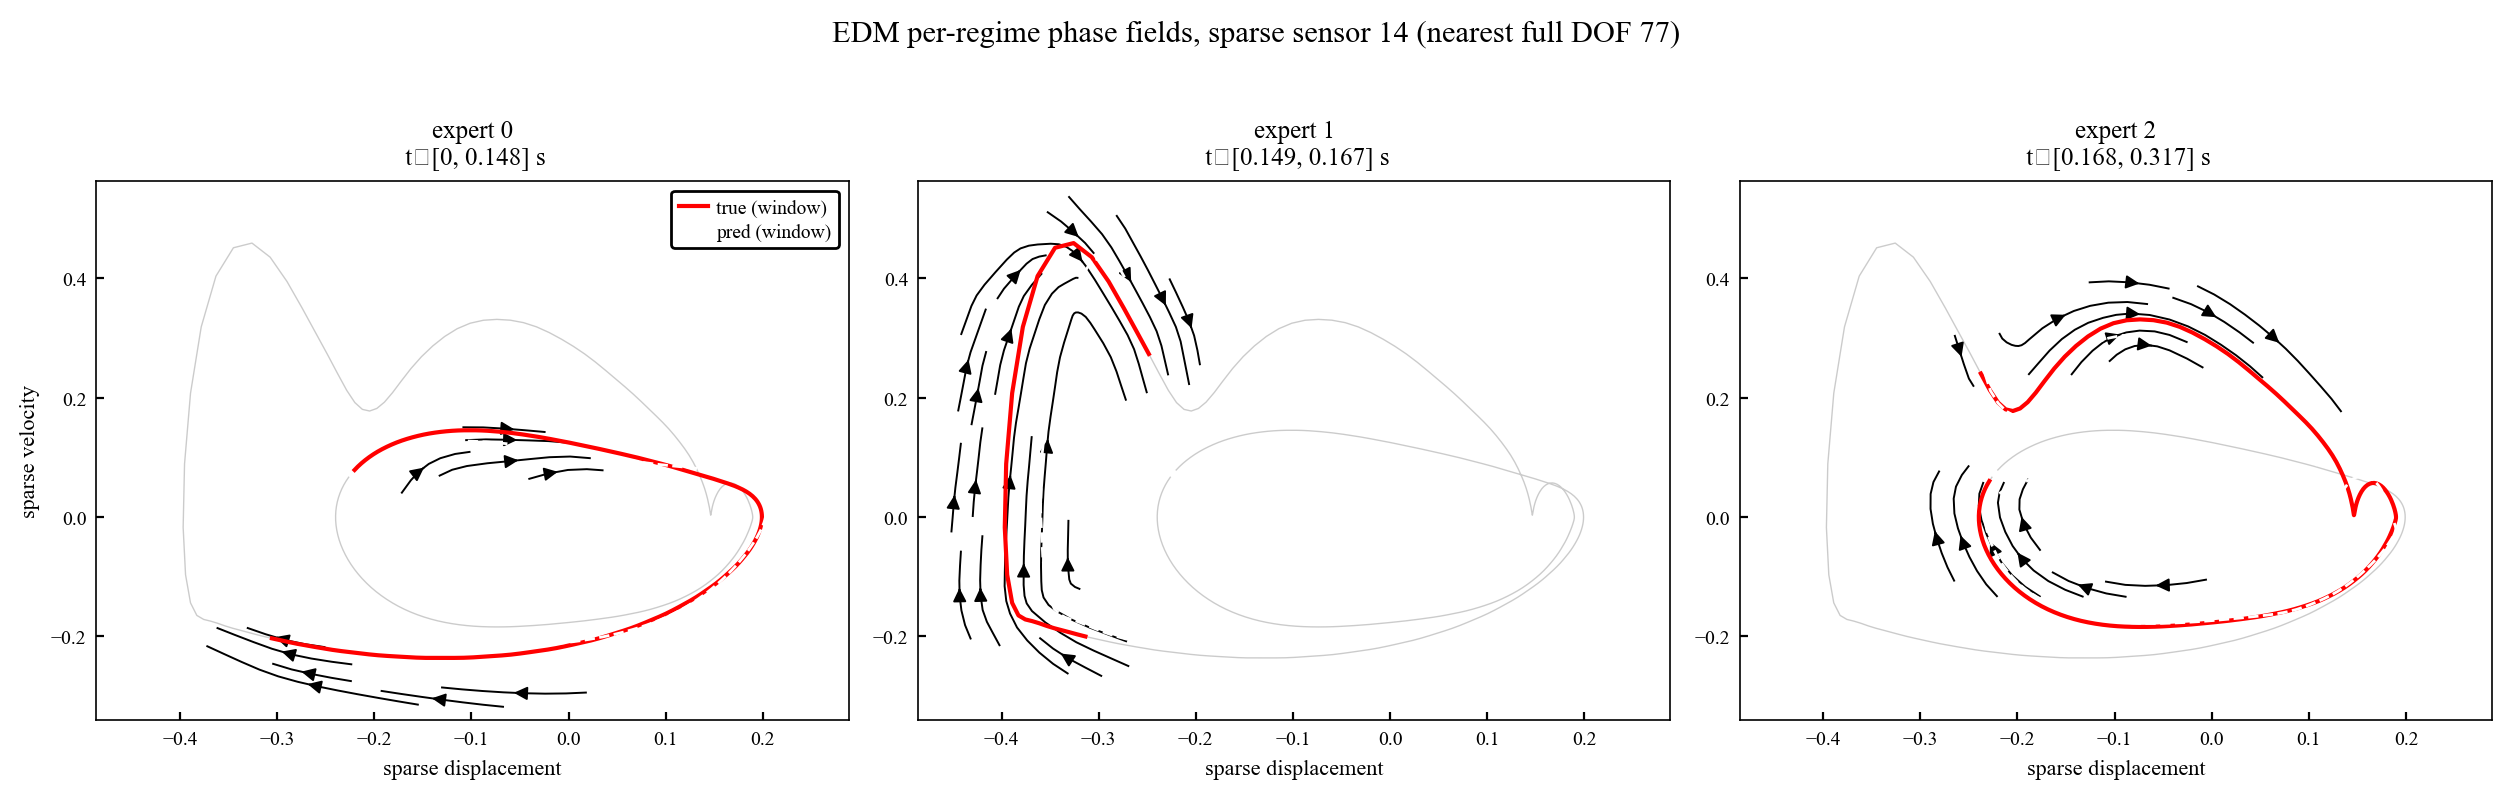

In [22]:
# %% Produce both, and save everything.
x, p = 75, 0
tag = f"cluster{cluster}_sample{p}_x{x}"

# Per-regime panels (this call already saves its own PNG via savepath).
panel_out = plot_regime_phase_fields(
    model=model, RS_reference=RS_test, ft_reference=ft_test, t=t, dt=dt,
    n_sparse=n_sparse, gate_weights=gate_weights[p], full_dof_idx=x,
    RS_pred_sparse=FS_pred_sparse, nx=nx, sensor_placement=sensor_placement,
    sample_idx=p, n_grid=45, mask_dist=0.10, manual_bounds=None, show_background=False,
    savepath=os.path.join("C:\\Users\\haida\\Desktop\\gated_node_lab\\tests", f"phase_field_panels_{tag}.png"),
    device=device,
)



In [ ]:
merge_out = merge_and_save_phase_fields(
    model=model, RS_reference=RS_test, ft_reference=ft_test, t=t, dt=dt,
    n_sparse=n_sparse, gate_weights=gate_weights[p], full_dof_idx=x,
    RS_pred_sparse=FS_pred_sparse, nx=nx, sensor_placement=sensor_placement,
    sample_idx=p, n_grid=60, mask_dist=0.1, regime_fields=panel_out["fields"],
    tag=tag,
    show_background=False,      # True to bring the speed gradient back
    stream_color="expert",      # or "black"
    device=device,
)